# Session 8: Software for Data Analysis IV

NYU SPS Accelerated Data Analytics  
Wed, Sept. 23  
Python commands for cleaning data and addressing common data challenges, including missing data.

---

## Session Overview
This session introduces students to the practical reality that workplace datasets are often incomplete, inconsistent, unclear, or otherwise messy. Students will learn how to identify common data quality problems and use beginner-friendly Python/pandas commands to clean and prepare a dataset for analysis. The session emphasizes not only the technical steps of cleaning data, but also the importance of documenting decisions so that analysis can be reviewed, repeated, and explained to others.

By the end of the session, students should understand that data cleaning is not simply a mechanical task. Every cleaning decision can affect the results of an analysis, so students must learn to make reasonable decisions, explain those decisions clearly, and avoid silently changing data in ways that could mislead a reader or stakeholder.

---

## Learning Objectives
* Identify common data quality problems.
* Find and summarize missing values.
* Rename columns so that datasets are easier to read and analyze.
* Filter rows based on conditions.
* Recode inconsistent categories.
* Create calculated columns.
* Document cleaning decisions in a short cleaning log.

# NYC 311: getting data ready for analysis

Today we will inspect June, July, and August 2026 requests, find missing values,
rename columns, standardize categories, filter rows, calculate new values, and
explain our decisions in a cleaning log.

**How to use this notebook**
- Upload and save your own copy in Colab. Run one code cell at a time with **Shift+Enter**.
- Read **Look for** after each step. Stop and interpret the output before continuing.
- A *DataFrame* is a table. We call our main table `df` throughout the lesson.
- After a runtime restart, run the cells again from the top. Variables do not survive a restart.
- If a cell fails, read its final error line. Fix that cell before moving on.



## Setup: download the class CSV from Google Drive
This cell is prepared for you. Run it once; you do not need to memorize the code.

It downloads the class dataset, Summer_2026_311.csv, from Google Drive into the Google Colab runtime. This file contains NYC 311 service requests from June, July, and August 2026.

At this stage, we are only downloading the CSV file. We are not yet loading the data into pandas or creating a DataFrame. We will do that in the next step using pd.read_csv().

The code first checks whether the file is already available in the current Colab session. If it is, the download is skipped. If it is not, the file is downloaded from Google Drive.

Because the dataset is large, the code downloads it to a temporary filename first. Only after the download finishes successfully is it renamed Summer_2026_311.csv. This helps prevent an incomplete download from being mistaken for the completed dataset.


### What Each Package Does

* **`from pathlib import Path`**
* **What it is:** A built-in Python tool for handling folder locations and filenames.
* **Why we use it:** Instead of worrying about slash directions (`/` vs `\`) across different operating systems (Windows vs. Mac/Linux), `Path` makes file paths safe, readable, and easy to join.


* **`from IPython.display import display`**
* **What it is:** A special display helper for Jupyter Notebooks and Google Colab.
* **Why we use it:** While Python's standard `print()` command outputs plain text, `display()` formats data tables (DataFrames) into clean, interactive visual grid formats directly in your notebook cells.


* **`import pandas as pd`**
* **What it is:** The standard library for working with tabular data (spreadsheets).
* **Why we use it:** Pandas allows us to load CSV files, clean missing values, filter rows, group numbers, and compute statistics. The `as pd` part is an industry-standard shortcut so we don't have to type `pandas` every time.


* **`import importlib.util`**
* **What it is:** A built-in Python utility that inspects installed software libraries.
* **Why we use it:** It lets our script automatically check if a required third-party tool (like `gdown` for downloading Google Drive files) is already installed before trying to run it.


* **`import subprocess`**
* **What it is:** A tool that allows Python code to talk directly to your computer's terminal (command line).
* **Why we use it:** If a required package is missing, `subprocess` allows Python to run a background terminal command (like `pip install package_name`) to download and install it for you automatically.


* **`import sys`**
* **What it is:** A core Python module that provides details about the active system environment.
* **Why we use it:** `sys.executable` tells Python the exact installation path of the current interpreter. This guarantees that any automatically installed packages go into the exact same folder your notebook is currently running from.


In [1]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import importlib.util
import subprocess
import sys

# Class default: June, July, and August.
FILE_ID = '10eDBCI2roDIuC2VJecwSuu47lJPkJfPe'
# August only (optional): FILE_ID = '1Ayf4NjJGKVpXjDscRhyAAULzrjOUHKSb'

DATA_PATH = Path('/content') / f'nyc311_{FILE_ID}.csv'

if importlib.util.find_spec('gdown') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
import gdown

if not DATA_PATH.exists():
    # Only a completed download receives the final filename.
    temporary_path = DATA_PATH.with_suffix('.download')
    result = gdown.download(id=FILE_ID, output=str(temporary_path), quiet=False)
    if result is None:
        raise RuntimeError('Download failed. Try the Drive-mount alternative below.')
    temporary_path.replace(DATA_PATH)

print('CSV ready:', DATA_PATH.name)
print('File size (MB):', round(DATA_PATH.stat().st_size / 1_000_000, 1))


Downloading...
From (original): https://drive.google.com/uc?id=10eDBCI2roDIuC2VJecwSuu47lJPkJfPe
From (redirected): https://drive.google.com/uc?id=10eDBCI2roDIuC2VJecwSuu47lJPkJfPe&confirm=t&uuid=5a333e42-4c01-4c89-8e90-cb4722f16e04
To: /content/nyc311_10eDBCI2roDIuC2VJecwSuu47lJPkJfPe.download
100%|██████████| 888M/888M [00:09<00:00, 92.4MB/s]

CSV ready: nyc311_10eDBCI2roDIuC2VJecwSuu47lJPkJfPe.csv
File size (MB): 887.7


## 1. Load and inspect the data
### 1A. Choose the columns
`read_csv()` reads a CSV into a table. `usecols` selects columns, **not rows**.
We load 11 useful fields and keep every row. We read text first to preserve IDs,
ZIP codes, and the original date strings.

The dictionary below also records the shorter names we will use later. Each pair
means **original name: new name**. Do not edit the original names unless the
source file uses different headings.


In [2]:
column_names = {
    'Unique Key': 'request_id',
    'Created Date': 'created_date',
    'Closed Date': 'closed_date',
    'Agency': 'agency',
    'Problem (formerly Complaint Type)': 'problem',
    'Problem Detail (formerly Descriptor)': 'problem_detail',
    'Location Type': 'location_type',
    'Incident Zip': 'incident_zip',
    'Status': 'status',
    'Borough': 'borough',
    'Open Data Channel Type': 'channel',
}

df = pd.read_csv(
    DATA_PATH,
    usecols=list(column_names),
    dtype='string',
    keep_default_na=False,
    na_values=['']
)
starting_rows = len(df)
print(f'Loaded {starting_rows:,} requests and {df.shape[1]} columns.')


Loaded 1,006,276 requests and 11 columns.


**Look for:** the number of rows and columns. The full summer snapshot has
1,006,276 requests; the month check below verifies your actual file. We do not
keep an extra full copy or reload the entire CSV for inspection. The CSV itself
is unchanged. Empty CSV cells become missing values; literal `N/A` remains text
so we can discuss its meaning.

### 1B. Rename and preview
`rename()` changes column headings. `head()` shows a few records; it cannot tell
us everything about a million-row dataset.


In [3]:
df = df.rename(columns=column_names)
original_fields = df.columns.tolist()
print('Column names:', original_fields)
display(df[['request_id', 'created_date', 'borough', 'problem', 'status']].head())


Column names: ['request_id', 'created_date', 'closed_date', 'agency', 'problem', 'problem_detail', 'location_type', 'incident_zip', 'status', 'borough', 'channel']


,request_id,created_date,borough,problem,status
0,70259761,08/31/2026 11:59:50 PM,MANHATTAN,Lost Property,Closed
1,70255217,08/31/2026 11:59:30 PM,BROOKLYN,For Hire Vehicle Complaint,In Progress
2,70257205,08/31/2026 11:59:27 PM,QUEENS,Noise - Street/Sidewalk,Closed
3,70258319,08/31/2026 11:59:25 PM,QUEENS,DOOR/WINDOW,Open
4,70259363,08/31/2026 11:59:21 PM,BRONX,Sewer Maintenance,Closed


In [4]:
# info() reports column names, non-missing counts, and data types.
df.info()

print('Missing request IDs:', df['request_id'].isna().sum())
print('Repeated request IDs:', df['request_id'].duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006276 entries, 0 to 1006275
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   request_id      1006276 non-null  string
 1   created_date    1006276 non-null  string
 2   closed_date     913369 non-null   string
 3   agency          1006276 non-null  string
 4   problem         1006276 non-null  string
 5   problem_detail  1006276 non-null  string
 6   location_type   883115 non-null   string
 7   incident_zip    997900 non-null   string
 8   status          1006276 non-null  string
 9   borough         1006276 non-null  string
 10  channel         1006276 non-null  string
dtypes: string(11)
memory usage: 84.5 MB
Missing request IDs: 0
Repeated request IDs: 0


**Discuss:** What does one row represent? Similar requests are not automatically
duplicates. Investigate repeated IDs if found; do not delete records merely
because the borough and problem are the same.

### 1C. Turn date text into dates
`to_datetime()` lets us use date operations. The format matches this export's
month/day/year and 12-hour clock. `errors='coerce'` makes an unreadable value
missing, so we count conversion failures before trusting the result.


In [5]:
date_format = '%m/%d/%Y %I:%M:%S %p'
df['created_at'] = pd.to_datetime(df['created_date'], format=date_format, errors='coerce')
df['closed_at'] = pd.to_datetime(df['closed_date'], format=date_format, errors='coerce')

created_failed = df['created_date'].notna() & df['created_at'].isna()
closed_failed = df['closed_date'].notna() & df['closed_at'].isna()
print('Nonblank creation dates that failed:', created_failed.sum())
print('Nonblank closure dates that failed:', closed_failed.sum())


Nonblank creation dates that failed: 0
Nonblank closure dates that failed: 0


In [6]:
# A new column: the month in which each request was created.
df['created_month'] = df['created_at'].dt.to_period('M').astype('string')
month_counts = df['created_month'].value_counts(dropna=False).sort_index()
display(month_counts.rename('requests').to_frame())

expected_months = ['2026-06', '2026-07', '2026-08']
missing_months = [month for month in expected_months if month not in month_counts.index]
if missing_months:
    print('STOP AND CHECK: months missing from this file:', missing_months)
    print('For the three-month class, select the summer FILE_ID and rerun from setup.')
else:
    print('June, July, and August are all present.')


,requests
created_month,
2026-06,334833
2026-07,343043
2026-08,328400


June, July, and August are all present.


**Look for:** all three creation months. If you selected August only, June and
July should be reported missing. Do not interpret an absent month as zero requests.
If conversion failures are nonzero, inspect those original strings with your
instructor. The raw date columns remain available.


## 2. Find missing values
### 2A. Count and calculate percentages
`isna()` asks whether a value is missing. `sum()` counts those True answers.
The percentage is the count divided by the number of requests, multiplied by 100.


In [7]:
missing_counts = df[original_fields].isna().sum()
missing_percent = 100 * missing_counts / len(df)
missing_table = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent.round(2)
})
display(missing_table.sort_values('missing_count', ascending=False))


,missing_count,missing_percent
location_type,123161,12.24
closed_date,92907,9.23
incident_zip,8376,0.83
created_date,0,0.00
request_id,0,0.00
problem,0,0.00
agency,0,0.00
problem_detail,0,0.00
status,0,0.00
borough,0,0.00


### 2B. Compare months
We create a True/False flag for a missing closure date. Grouping by creation month
lets us compare percentages even when the months contain different row counts.
`size` counts rows, `sum` counts True flags, and `mean` gives the fraction True.


In [8]:
df['closed_date_missing'] = df['closed_at'].isna()
missing_by_month = df.groupby('created_month')['closed_date_missing'].agg(['size', 'sum', 'mean'])
missing_by_month.columns = ['requests', 'missing_closed_date', 'missing_fraction']
missing_by_month['missing_percent'] = (100 * missing_by_month['missing_fraction']).round(2)
display(missing_by_month[['requests', 'missing_closed_date', 'missing_percent']])


,requests,missing_closed_date,missing_percent
created_month,,,
2026-06,334833,16792,5.02
2026-07,343043,27030,7.88
2026-08,328400,49085,14.95


### 2C. A label can also mean “unknown”
`isna()` does not count literal labels that we preserved during import. Do not
assume `N/A` means “unknown” or “not applicable” without checking the source rule.


In [9]:
display(df['borough'].value_counts(dropna=False).rename('requests').to_frame())
print('Literal N/A in problem detail:', (df['problem_detail'] == 'N/A').sum())
print('Literal N/A in location type:', (df['location_type'] == 'N/A').sum())


,requests
borough,
BROOKLYN,313113
QUEENS,261079
BRONX,202273
MANHATTAN,188144
STATEN ISLAND,40432
Unspecified,1235


Literal N/A in problem detail: 29092
Literal N/A in location type: 3399


**Pause:** Would you replace an unknown duration with zero? Why might a request
with no closure date still belong in a count of requests?

**Our decision:** keep the request, keep the date missing, and flag it. Later
requests have had less time to close in a fixed snapshot. A higher missing-closure
percentage alone does not prove slower service. Do not fill unknown dates with
zero or delete all rows with any missing field.


## 3. Recode categories
### 3A. Inspect before changing anything
`value_counts()` tells us how often each label appears. Look for capitalization
and spelling differences, and decide whether the labels really mean the same thing.


In [10]:
display(df['location_type'].value_counts(dropna=False).head(15).rename('requests').to_frame())


,requests
location_type,
Street/Sidewalk,342306
RESIDENTIAL BUILDING,157193
<NA>,123161
Street,112750
Residential Building/House,107309
Sidewalk,55111
Store/Commercial,15299
Park,12885
Park/Playground,6728


### 3B. Make one explicit change
We combine the capitalization-only variation `RESIDENTIAL BUILDING` with
`Residential Building` in a **new column**. We preserve the original field.
We do not automatically merge `Residential Building/House` into it.


In [11]:
df['location_type_clean'] = df['location_type'].str.strip()
df['location_type_clean'] = df['location_type_clean'].replace({
    'RESIDENTIAL BUILDING': 'Residential Building'
})

location_changed = (df['location_type'] != df['location_type_clean']).fillna(False)
print('Rows whose label changed:', location_changed.sum())

before_after = pd.DataFrame({
    'before': df['location_type'].value_counts(dropna=False),
    'after': df['location_type_clean'].value_counts(dropna=False)
}).fillna(0).astype(int)
display(before_after.reindex(['RESIDENTIAL BUILDING', 'Residential Building'], fill_value=0))


Rows whose label changed: 157193


,before,after
RESIDENTIAL BUILDING,157193,0
Residential Building,3734,160927


**Look for:** the two labels becoming one without adding or removing requests.
If one label is absent in your file, the displayed count is zero. `str.strip()`
removes outer spaces if present; do not claim there were spaces unless you checked.

**Try explaining:** “We changed ___ because ___. We kept ___ unchanged because ___.”


## 4. Filter rows
**Question:** How many residential-noise requests were created in Brooklyn each month?
A comparison such as `df['borough'] == 'BROOKLYN'` gives True/False for each row.
Parentheses group each condition; `&` means both must be true.


In [12]:
# First, count all Brooklyn requests without making another full table.
brooklyn_rows = df['borough'] == 'BROOKLYN'
print('Brooklyn requests:', brooklyn_rows.sum())

# Now keep only the columns needed to answer the narrower question.
noise_rows = df['problem'] == 'Noise - Residential'
brooklyn_noise = df.loc[
    brooklyn_rows & noise_rows,
    ['request_id', 'created_month', 'borough', 'problem']
].copy()
display(brooklyn_noise['created_month'].value_counts().sort_index().rename('requests').to_frame())
print('The main table still has', len(df), 'rows.')


Brooklyn requests: 313113


,requests
created_month,
2026-06,10238
2026-07,9628
2026-08,10205


The main table still has 1006276 rows.


**Your turn:** Which text would you change to study Queens? What would `|` (OR)
select instead of `&` (AND)? These are counts of requests, not unique residents
or verified incidents. Our filter creates a separate subset and leaves `df` intact.


## 5. Create calculated columns
### 5A. Calculate recorded hours to closure
Subtract creation time from closure time. Convert the result to seconds, then
divide by 3,600. Call this **recorded time to closure**, not first-response time
or proof that the problem was resolved.


In [13]:
time_difference = df['closed_at'] - df['created_at']
df['hours_to_close_raw'] = time_difference.dt.total_seconds() / 3600

df['negative_duration'] = df['hours_to_close_raw'] < 0
print('Negative intervals:', df['negative_duration'].sum())
print('Zero intervals:', (df['hours_to_close_raw'] == 0).sum())
display(df.loc[df['negative_duration'],
               ['request_id', 'created_date', 'closed_date', 'hours_to_close_raw']].head())


Negative intervals: 488
Zero intervals: 24737


,request_id,created_date,closed_date,hours_to_close_raw
651,70257821,08/31/2026 10:15:15 PM,08/31/2026 10:15:00 PM,-0.004167
1779,70250292,08/31/2026 07:50:04 PM,08/31/2026 07:50:00 PM,-0.001111
3559,70259346,08/31/2026 04:40:10 PM,08/31/2026 04:40:00 PM,-0.002778
4590,70257823,08/31/2026 03:02:07 PM,08/31/2026 03:02:00 PM,-0.001944
5819,70257826,08/31/2026 01:09:22 PM,08/31/2026 01:09:00 PM,-0.006111


**Discuss:** A negative interval is inconsistent with this calculation. We cannot
know which timestamp is wrong. Taking its absolute value would invent a correction.
Keep the request and flag it. A zero interval is retained, but does not prove instant service.

### 5B. Decide which durations to summarize
For this lesson, an eligible duration requires Closed status and a nonnegative
interval. A missing interval is not eligible. We retain **all requests** and put
only eligible durations in the new analysis column.


In [14]:
is_closed = df['status'] == 'Closed'
has_valid_duration = df['hours_to_close_raw'] >= 0
df['duration_eligible'] = (is_closed & has_valid_duration).fillna(False)
df['hours_to_close'] = df['hours_to_close_raw'].where(df['duration_eligible'])

print('All requests:', len(df))
print('Eligible durations:', df['hours_to_close'].notna().sum())
print('Excluded from the duration summary:', df['hours_to_close'].isna().sum())


All requests: 1006276
Eligible durations: 901046
Excluded from the duration summary: 105230


### 5C. Make a flag that preserves “unknown”
A duration over 24 hours is True; a known duration of 24 or less is False.
Missing stays missing. This threshold is a teaching example, not an official
service standard. Lowercase `boolean` supports a third, missing state.


In [15]:
df['over_24_hours'] = (df['hours_to_close'] > 24).astype('boolean')
unknown_duration = df['hours_to_close'].isna()
df.loc[unknown_duration, 'over_24_hours'] = pd.NA
display(df['over_24_hours'].value_counts(dropna=False).rename('requests').to_frame())


,requests
over_24_hours,
False,594804
True,306242
<NA>,105230


### 5D. Read the summary carefully
This prepared summary groups requests by **creation month**. `size` counts all
requests, while `count` counts only available durations. Read both denominators.


In [16]:
monthly_summary = df.groupby('created_month').agg(
    requests=('request_id', 'size'),
    eligible_durations=('hours_to_close', 'count'),
    mean_hours=('hours_to_close', 'mean'),
    median_hours=('hours_to_close', 'median')
)
monthly_summary['excluded_from_duration'] = monthly_summary['requests'] - monthly_summary['eligible_durations']
display(monthly_summary.round(2))


,requests,eligible_durations,mean_hours,median_hours,excluded_from_duration
created_month,,,,,
2026-06,334833,316060,103.44,5.55,18773
2026-07,343043,312516,97.88,4.78,30527
2026-08,328400,272470,51.94,3.96,55930


**Look for:** mean versus median and how many requests contribute a duration.
Different problem mixes, incomplete records, and unequal follow-up time limit
comparisons. Do not use this table alone to rank borough or agency performance.
See [NYC's closure definitions](https://www.nyc.gov/site/311reporting/faq/faq.page).


## 6. Check your work and keep a log
### 6A. Check the results
Read the checks below. True means that particular check passed; it does not mean
that every field in the dataset is correct. If a result is False, pause and investigate.


In [17]:
checks = pd.Series({
    'All original requests retained': len(df) == starting_rows,
    'Column names are unique': df.columns.is_unique,
    'Category recode preserved missing values': df['location_type'].isna().sum() == df['location_type_clean'].isna().sum(),
    'Analyzed durations are nonnegative': (df['hours_to_close'].dropna() >= 0).all(),
    'Unknown durations have unknown flags': df['hours_to_close'].isna().equals(df['over_24_hours'].isna()),
    'Monthly counts include all loaded requests': monthly_summary['requests'].sum() == starting_rows,
    'All three class months are present': len(missing_months) == 0,
    'All nonblank dates parsed': created_failed.sum() + closed_failed.sum() == 0,
})
display(checks.rename('passed').to_frame())


,passed
All original requests retained,True
Column names are unique,True
Category recode preserved missing values,True
Analyzed durations are nonnegative,True
Unknown durations have unknown flags,True
Monthly counts include all loaded requests,True
All three class months are present,True
All nonblank dates parsed,True


### 6B. Record what you did and why
Start with three decisions. A log should explain the issue, action, reason, and
number of affected records. Keeping records can be a deliberate decision too.
These issue counts can overlap; do not add them to count “bad rows.”


In [18]:
cleaning_log = pd.DataFrame([
    ['Missing closure dates', 'Kept requests and flagged missing dates',
     'Unknown is not zero', int(df['closed_date_missing'].sum())],
    ['Location labels', 'Standardized one capitalization variation in a new column',
     'Combine equivalent labels; keep original values', int(location_changed.sum())],
    ['Duration eligibility', 'Used Closed status and nonnegative intervals for duration summaries',
     'Define the measured population; retain all requests', int((~df['duration_eligible']).sum())],
], columns=['issue', 'action', 'reason', 'affected_rows'])
cleaning_log['source_file'] = DATA_PATH.name
display(cleaning_log)


,issue,action,reason,affected_rows,source_file
0,Missing closure dates,Kept requests and flagged missing dates,Unknown is not zero,92907,nyc311_10eDBCI2roDIuC2VJecwSuu47lJPkJfPe.csv
1,Location labels,Standardized one capitalization variation in a...,Combine equivalent labels; keep original values,157193,nyc311_10eDBCI2roDIuC2VJecwSuu47lJPkJfPe.csv
2,Duration eligibility,Used Closed status and nonnegative intervals f...,Define the measured population; retain all req...,105230,nyc311_10eDBCI2roDIuC2VJecwSuu47lJPkJfPe.csv


## Breakout Room Activities:


## Lab A. Missing values
1. Reproduce missing closure counts and percentages by month.
2. Use the starter below to inspect another field; try `incident_zip` next.
3. Explain how an empty cell differs from the source labels `N/A` and `Unspecified`.
4. Write what you would retain, flag, or exclude for a particular question, and why.

**Discuss:** What more would you need to know before claiming August service was slower?


In [19]:
field_to_check = 'location_type'  # Try 'incident_zip' next.
lab_missing = df[field_to_check].isna().groupby(df['created_month']).agg(['size', 'sum', 'mean'])
lab_missing.columns = ['requests', 'missing_count', 'missing_fraction']
lab_missing['missing_percent'] = (100 * lab_missing['missing_fraction']).round(2)
display(lab_missing[['requests', 'missing_count', 'missing_percent']])


,requests,missing_count,missing_percent
created_month,,,
2026-06,334833,45756,13.67
2026-07,343043,51233,14.93
2026-08,328400,26172,7.97


**Your explanation:** Write two or three sentences here.


## Lab B. Categories
1. Verify the residential-building before/after table from the lecture.
2. Run the display-label cleanup below. Confirm that no records disappeared.
3. Explain why `Unspecified` still does not identify a known borough.
4. Explain why merging different labels, such as all noise categories, requires
   more justification than fixing capitalization.


In [20]:
df['borough_display'] = df['borough'].str.strip().str.title()
borough_counts = df['borough_display'].value_counts(dropna=False)
display(borough_counts.rename('requests').to_frame())
print('All requests accounted for:', borough_counts.sum() == starting_rows)


,requests
borough_display,
Brooklyn,313113
Queens,261079
Bronx,202273
Manhattan,188144
Staten Island,40432
Unspecified,1235


All requests accounted for: True


**Your explanation:** State one justified change and one change you would avoid.


## Lab C. Choose a question and filter
Start with **Queens + Illegal Parking** as a shared checkpoint. Then choose your
own borough and exact problem label from the source categories. State the question
before changing the code. An empty subset is a reason to check the labels.
Only months present in the source are displayed; a missing source month is not zero.


In [21]:
chosen_borough = 'QUEENS'
chosen_problem = 'Illegal Parking'

lab_rows = (df['borough'] == chosen_borough) & (df['problem'] == chosen_problem)
lab_df = df.loc[lab_rows, ['request_id', 'created_month', 'borough', 'problem', 'hours_to_close']].copy()
loaded_months = sorted(df['created_month'].dropna().unique())
lab_counts = lab_df['created_month'].value_counts().reindex(loaded_months, fill_value=0)
display(lab_counts.rename('requests').to_frame())
print('Selected requests:', len(lab_df))


,requests
created_month,
2026-06,17842
2026-07,16183
2026-08,16460


Selected requests: 50485


**Your question and interpretation:** Explain what was counted and the population it describes.


## Lab D. Calculate and explain
1. Run the starter to summarize your subset. Include both all requests and eligible durations.
2. Change the lecture's 24-hour threshold to **48 hours** in the new lab flag.
3. Verify that missing durations remain missing, rather than False.
4. Write a finding and one limitation. Explain why closure is not necessarily resolution.

A chart is optional. Finish the cleaning objectives before adding a visualization.


In [22]:
lab_summary = lab_df.groupby('created_month').agg(
    requests=('request_id', 'size'),
    eligible_durations=('hours_to_close', 'count'),
    mean_hours=('hours_to_close', 'mean'),
    median_hours=('hours_to_close', 'median')
).reindex(loaded_months)
# Zero requests is meaningful; a mean for zero observations stays missing.
lab_summary[['requests', 'eligible_durations']] = lab_summary[['requests', 'eligible_durations']].fillna(0).astype(int)
display(lab_summary.round(2))

lab_df['over_48_hours'] = (lab_df['hours_to_close'] > 48).astype('boolean')
lab_df.loc[lab_df['hours_to_close'].isna(), 'over_48_hours'] = pd.NA
display(lab_df['over_48_hours'].value_counts(dropna=False).rename('requests').to_frame())


,requests,eligible_durations,mean_hours,median_hours
created_month,,,,
2026-06,17842,17842,3.51,1.80
2026-07,16183,16132,3.01,1.58
2026-08,16460,16459,3.29,1.60


,requests
over_48_hours,
False,50411
<NA>,52
True,22


**Your finding and limitation:** Write them here.


# Data Vis. Activities:

## 7. Visualize Data: Monthly Trends (June – August 2026)

Now that our data is cleaned and standardized, we can plot key trends across the three summer months. Different chart types help us highlight different patterns:

* **Line Charts** show overall volume trends and monthly movement.
* **Grouped Bar Charts** allow direct side-by-side comparisons of distinct categories across months.
* **Stacked Bar Charts** illustrate composition and relative share (e.g., how boroughs contribute to total volume).

### 7A. Overall Monthly Request Volume (Line Chart)
A simple line chart shows whether total 311 service request activity increased or decreased across June, July, and August.

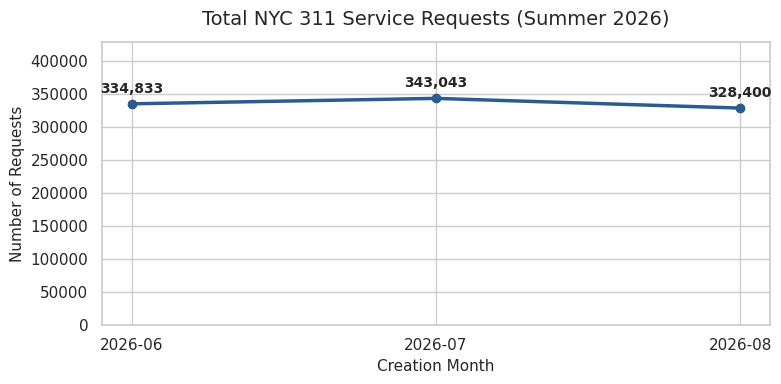

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Aggregate counts per month
monthly_counts = df['created_month'].value_counts().sort_index()

# Plot line chart
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linewidth=2.5, color='#2b5c8f')

plt.title('Total NYC 311 Service Requests (Summer 2026)', fontsize=14, pad=12)
plt.xlabel('Creation Month', fontsize=11)
plt.ylabel('Number of Requests', fontsize=11)
plt.ylim(0, monthly_counts.max() * 1.25)

# Annotate data points
for month, count in monthly_counts.items():
    plt.annotate(f'{count:,}',
                 (month, count),
                 textcoords="offset points",
                 xytext=(0, 8),
                 ha='center',
                 fontsize=10,
                 fontweight='bold')

plt.tight_layout()
plt.show()

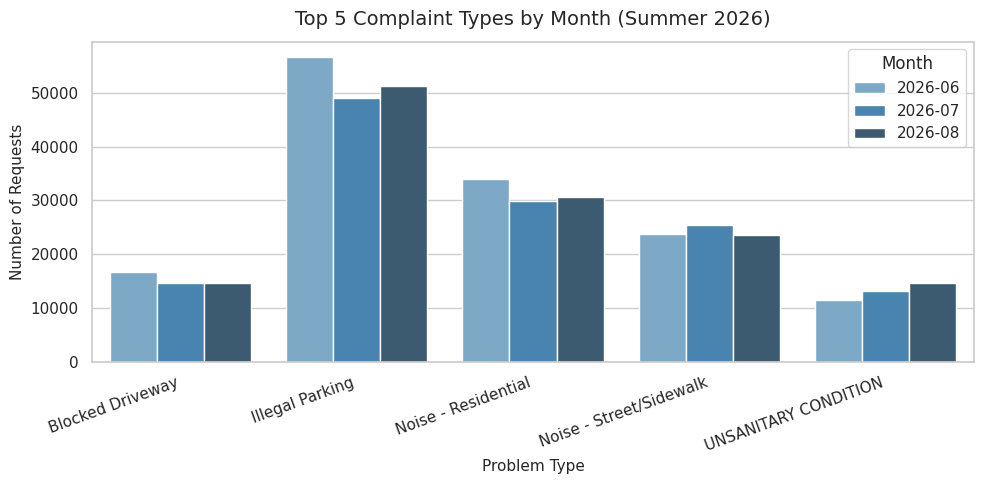

In [24]:
# Identify the top 5 most common problems overall
top_5_problems = df['problem'].value_counts().head(5).index

# Filter dataset to top 5 problems
top_problems_df = df[df['problem'].isin(top_5_problems)]

# Pivot data to get counts by Problem and Month
problem_monthly = (top_problems_df.groupby(['problem', 'created_month'])
                   .size()
                   .reset_index(name='count'))

# Plot Grouped Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=problem_monthly, x='problem', y='count', hue='created_month', palette='Blues_d')

plt.title('Top 5 Complaint Types by Month (Summer 2026)', fontsize=14, pad=12)
plt.xlabel('Problem Type', fontsize=11)
plt.ylabel('Number of Requests', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Month')

plt.tight_layout()
plt.show()

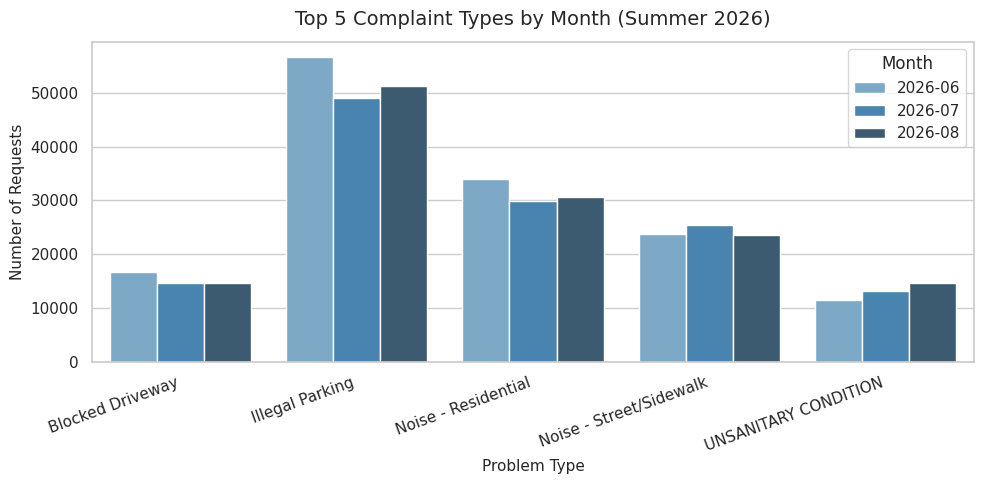

In [25]:
# Identify the top 5 most common problems overall
top_5_problems = df['problem'].value_counts().head(5).index

# Filter dataset to top 5 problems
top_problems_df = df[df['problem'].isin(top_5_problems)]

# Pivot data to get counts by Problem and Month
problem_monthly = (top_problems_df.groupby(['problem', 'created_month'])
                   .size()
                   .reset_index(name='count'))

# Plot Grouped Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=problem_monthly, x='problem', y='count', hue='created_month', palette='Blues_d')

plt.title('Top 5 Complaint Types by Month (Summer 2026)', fontsize=14, pad=12)
plt.xlabel('Problem Type', fontsize=11)
plt.ylabel('Number of Requests', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Month')

plt.tight_layout()
plt.show()

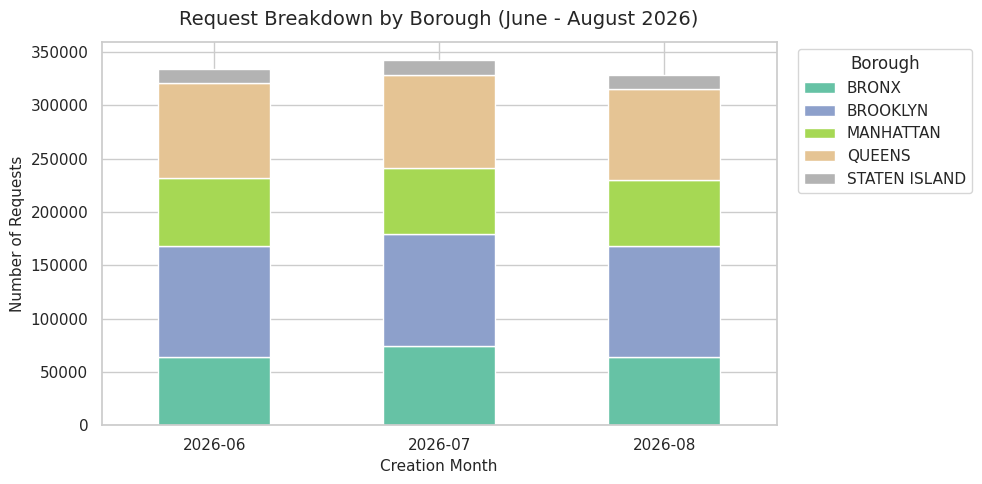

In [26]:
# Create pivot table: Boroughs as rows, Months as columns
borough_pivot = df.groupby(['created_month', 'borough']).size().unstack(fill_value=0)

# Filter out unassigned/unspecified boroughs for cleaner plotting
valid_boroughs = [b for b in borough_pivot.columns if b not in ['Unspecified', 'N/A', '']]
borough_pivot = borough_pivot[valid_boroughs]

# Plot Stacked Bar Chart
ax = borough_pivot.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2')

plt.title('Request Breakdown by Borough (June - August 2026)', fontsize=14, pad=12)
plt.xlabel('Creation Month', fontsize=11)
plt.ylabel('Number of Requests', fontsize=11)
plt.xticks(rotation=0)
plt.legend(title='Borough', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Quick help
| Message or symptom | What to do |
|---|---|
| `DATA_PATH` or `df` is not defined | Run setup and earlier cells in order. Restarted runtimes forget variables. |
| CSV download fails | Check access or use the Drive-mount alternative; copy the exact mounted path. |
| A required column is missing | Confirm the correct CSV. Compare `pd.read_csv(DATA_PATH, nrows=0).columns` with the mapping. |
| Only August appears | The August file was selected. Use the summer ID for the three-month class. |
| A filter returns zero rows | Inspect exact values and capitalization with `value_counts()`. |
| Colab runs out of memory | Restart the runtime and run this notebook from the top. Do not also load the full CSV into `august311` or keep old full-table copies. |

Sources: [Summer file](https://drive.google.com/file/d/10eDBCI2roDIuC2VJecwSuu47lJPkJfPe/view),
[August-only file](https://drive.google.com/file/d/1Ayf4NjJGKVpXjDscRhyAAULzrjOUHKSb/view),
[NYC 311 definitions](https://www.nyc.gov/site/311reporting/faq/faq.page),
[pandas CSV import](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html),
[Colab FAQ](https://research.google.com/colaboratory/faq.html).
